# 基于氧化应激相关基因的急性肝损伤机器学习诊断模型 —— 结果展示

本项目基于 GEO 公共转录组数据(GSE17649 小鼠训练集 / GSE111828 小鼠外部验证集 / GSE120652 人跨物种方向验证),
构建对乙酰氨基酚(APAP)急性肝损伤的诊断模型,并以氧化应激(GO:0006979)基因集进行机制锚定。

本笔记本**只读展示**已由 `scripts/` 全流程生成的结果文件,并做两项可复现性检查:

1. 从 `validation_predictions.csv` 的逐样本预测概率**重新计算**外部验证 AUC,与 `validation_auc.csv` 存储值核对;
2. 打印完整运行环境版本,配合根目录 `requirements.txt` 复现 Python 依赖。

> R 侧全流程(数据下载→DEG→建模→验证→富集)复现方式见 README: `bash scripts/run_all.sh`(conda env `rna`,随机种子固定)。

## 0. 环境与全局设置

固定随机种子;所有路径均为仓库相对路径,不依赖绝对路径。

In [1]:
import random, sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

# 笔记本位于 notebooks/ 下,自动向上定位仓库根目录
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir())
print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("platform    :", platform.platform())

Python      : 3.12.10
numpy       : 2.3.5
pandas      : 3.0.2
matplotlib  : 3.10.9
scikit-learn: 1.9.0
platform    : Windows-11-10.0.26200-SP0


检查分析产物是否齐全:

In [2]:
REQUIRED = [
    "data/os_genes_human.csv", "data/os_genes_mouse.csv",
    "results/de_all_GSE17649.csv", "results/deg_GSE17649.csv",
    "results/os_deg_GSE17649.csv",
    "results/ml_cv_results.csv", "results/lasso_coefficients.csv",
    "results/rf_importance.csv", "results/xgb_importance.csv",
    "results/validation_auc.csv", "results/validation_predictions.csv",
    "results/enrichment_go_BP.csv", "results/enrichment_kegg.csv",
    "results/enrichment_dotplot.png", "results/roc_training.png",
    "results/roc_validation.png", "results/crossspecies_GSE120652.csv",
]
missing = [f for f in REQUIRED if not (ROOT / f).is_file()]
assert not missing, f"缺少结果文件: {missing}"
print(f"仓库根目录: {ROOT.resolve().parent.name}/{ROOT.name}")
print(f"全部 {len(REQUIRED)} 个输入文件就位,可独立复现本笔记本。")

仓库根目录: Desktop/os-ali-project
全部 17 个输入文件就位,可独立复现本笔记本。


## 1. 氧化应激相关基因集

训练集物种为小鼠,基因集由 GO:0006979 (response to oxidative stress) 出发,
经 MGI/UniProt 同源映射得到人/鼠两套基因符号表:

In [3]:
human_gs = pd.read_csv(ROOT / "data/os_genes_human.csv")
mouse_gs = pd.read_csv(ROOT / "data/os_genes_mouse.csv")
print(f"人 OS 基因集: {len(human_gs)} 个基因 | 小鼠 OS 基因集: {len(mouse_gs)} 个基因")
human_gs.head(10)

人 OS 基因集: 154 个基因 | 小鼠 OS 基因集: 174 个基因


,gene_symbol,uniprot_id
0,ABL1,P00519
1,ADRM1,Q16186
2,AKT1,P31749
3,ALAD,P13716
4,ALDH3B1,P43353
5,ANGPTL7,O43827
6,ATE1,O95260
7,ATM,Q13315
8,ATOX1,O00244
9,BANF1,O75531


## 2. 差异表达分析(GSE17649, APAP 3-6h vs 0h)

火山图直接由全探针表 `de_all_GSE17649.csv` 重绘(阈值: `adj.P.Val < 0.05` 且 `|logFC| > 1`):

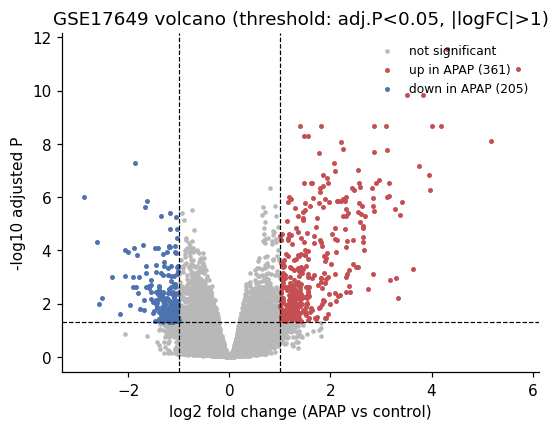

显著 DEGs(与 R 管线输出的 deg_GSE17649.csv 一致): 566 个(上调 361 / 下调 205)


In [4]:
de_all = pd.read_csv(ROOT / "results/de_all_GSE17649.csv")
deg = pd.read_csv(ROOT / "results/deg_GSE17649.csv")
sig = (de_all["adj.P.Val"] < 0.05) & (de_all["logFC"].abs() > 1)

fig, ax = plt.subplots(figsize=(5.6, 4))
ax.scatter(de_all.loc[~sig, "logFC"], -np.log10(de_all.loc[~sig, "adj.P.Val"]),
           s=4, c="#b8b8b8", label="not significant")
up = sig & (de_all["logFC"] > 0)
dn = sig & (de_all["logFC"] < 0)
ax.scatter(de_all.loc[up, "logFC"], -np.log10(de_all.loc[up, "adj.P.Val"]),
           s=5, c="#c44e52", label=f"up in APAP ({up.sum()})")
ax.scatter(de_all.loc[dn, "logFC"], -np.log10(de_all.loc[dn, "adj.P.Val"]),
           s=5, c="#4c72b0", label=f"down in APAP ({dn.sum()})")
ax.axhline(-np.log10(0.05), ls="--", lw=0.8, c="k")
ax.axvline(1, ls="--", lw=0.8, c="k")
ax.axvline(-1, ls="--", lw=0.8, c="k")
ax.set_xlabel("log2 fold change (APAP vs control)")
ax.set_ylabel("-log10 adjusted P")
ax.set_title("GSE17649 volcano (threshold: adj.P<0.05, |logFC|>1)")
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.show()

print(f"显著 DEGs(与 R 管线输出的 deg_GSE17649.csv 一致): {len(deg)} 个"
      f"(上调 {(deg['logFC'] > 0).sum()} / 下调 {(deg['logFC'] < 0).sum()})")

氧化应激相关 DEGs(OS-DEGs):DEGs 与 OS 基因集的交集,即建模与机制解释的核心基因。

In [5]:
os_deg = pd.read_csv(ROOT / "results/os_deg_GSE17649.csv")
print(f"OS-DEGs: {os_deg['probe'].nunique()} 探针 / {os_deg['gene_symbol'].nunique()} 基因")
print("基因:", ", ".join(sorted(os_deg['gene_symbol'].unique())))
os_deg[['gene_symbol', 'probe', 'logFC', 'P.Value', 'adj.P.Val']].sort_values('logFC', ascending=False)

OS-DEGs: 12 探针 / 8 基因
基因: Btg1, Gclc, Hmox1, Itch, Rcan1, Srxn1, Txnrd1, Xpa


,gene_symbol,probe,logFC,P.Value,adj.P.Val
0,Hmox1,1448239_at,3.833643,1.242772e-14,1.401257e-10
1,Srxn1,1425351_at,2.613554,7.906658e-09,4.245217e-06
3,Srxn1,1451680_at,2.120090,1.292420e-07,4.223871e-05
2,Srxn1,1426875_s_at,2.020817,6.052742e-08,2.337336e-05
6,Btg1,1442018_at,1.885698,1.250418e-06,2.506448e-04
5,Rcan1,1416600_a_at,1.487573,3.904945e-07,1.000664e-04
7,Gclc,1424296_at,1.416935,2.444245e-06,4.223675e-04
10,Rcan1,1416601_a_at,1.399926,2.276366e-05,2.317526e-03
8,Gclc,1455959_s_at,1.354365,2.915451e-06,4.798896e-04
9,Txnrd1,1421529_a_at,1.058855,1.557179e-05,1.742688e-03


## 3. 机器学习诊断模型(GSE17649 训练集)

三种模型:LASSO 逻辑回归 / 随机森林 / XGBoost,均为**分层 5×5 折交叉验证**,标准化在每折训练折内部完成(z-score),避免信息泄漏。

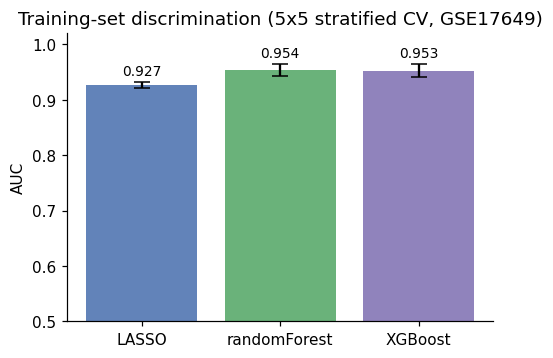

,model,AUC均值,AUC标准差
0,LASSO,0.9271,0.0055
1,randomForest,0.9538,0.0112
2,XGBoost,0.9528,0.0119


In [6]:
cv = pd.read_csv(ROOT / "results/ml_cv_results.csv")
fig, ax = plt.subplots(figsize=(5, 3.4))
bars = ax.bar(cv["model"], cv["auc_mean"], yerr=cv["auc_sd"], capsize=5,
              color=["#4c72b0", "#55a868", "#8172b3"], alpha=0.88)
for b, m, s in zip(bars, cv["auc_mean"], cv["auc_sd"]):
    ax.text(b.get_x() + b.get_width() / 2, m + s + 0.012, f"{m:.3f}",
            ha="center", fontsize=9)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("AUC")
ax.set_title("Training-set discrimination (5x5 stratified CV, GSE17649)")
plt.show()
cv.rename(columns={"auc_mean": "AUC均值", "auc_sd": "AUC标准差"})

三个模型各自的特征重要性(LASSO 系数为带符号值,正=上调风险方向):

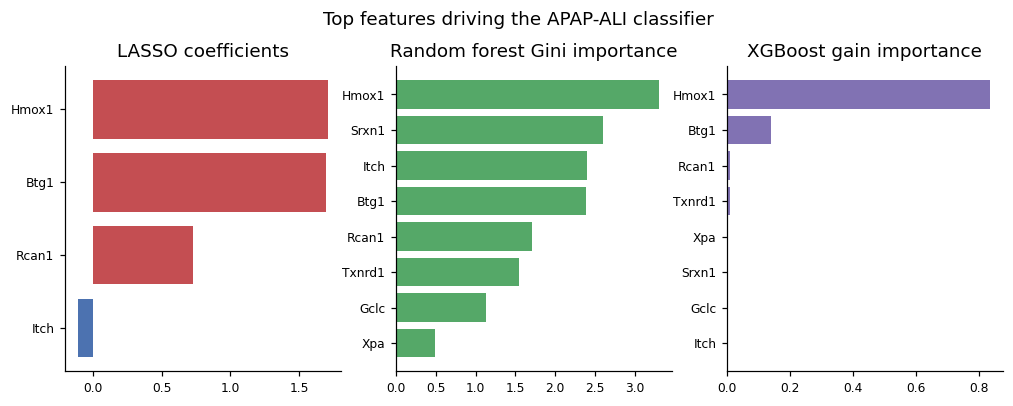

In [7]:
lasso = pd.read_csv(ROOT / "results/lasso_coefficients.csv")
lasso = lasso[lasso["gene"] != "(Intercept)"].sort_values("coefficient")
rf = pd.read_csv(ROOT / "results/rf_importance.csv").sort_values("MeanDecreaseGini")
xgb = pd.read_csv(ROOT / "results/xgb_importance.csv").sort_values("gain")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].barh(lasso["gene"], lasso["coefficient"],
             color=np.where(lasso["coefficient"] > 0, "#c44e52", "#4c72b0"))
axes[0].set_title("LASSO coefficients")
axes[1].barh(rf["gene"], rf["MeanDecreaseGini"], color="#55a868")
axes[1].set_title("Random forest Gini importance")
axes[2].barh(xgb["feature"], xgb["gain"], color="#8172b3")
axes[2].set_title("XGBoost gain importance")
for ax in axes:
    ax.tick_params(labelsize=8)
fig.suptitle("Top features driving the APAP-ALI classifier", y=1.02)
plt.show()

## 4. 外部验证(GSE111828, 独立小鼠 RNA-seq)

**可复现性核对**:下表右侧两列分别为"由逐样本预测概率现场重算的 AUC"与"R 管线存储的 AUC",
两者应在容差内一致(断言通过才会显示本单元格输出)。

外部集样本: n=24(APAP 20 / Control 4)


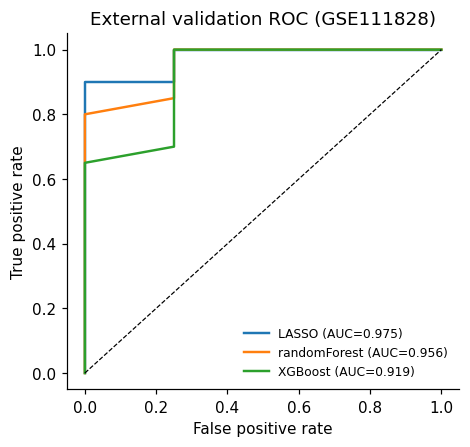

,model,重算AUC,存储AUC,一致
0,LASSO,0.9750,0.9750,True
1,randomForest,0.9563,0.9562,True
2,XGBoost,0.9187,0.9188,True


In [8]:
pred = pd.read_csv(ROOT / "results/validation_predictions.csv")
auc_tab = pd.read_csv(ROOT / "results/validation_auc.csv")
y_true = (pred["group"] != "Control").astype(int)  # APAP=1, Control=0
print(f"外部集样本: n={len(pred)}(APAP {(y_true == 1).sum()} / Control {(y_true == 0).sum()})")

fig, ax = plt.subplots(figsize=(4.6, 4.2))
rows = []
for model in ["LASSO", "randomForest", "XGBoost"]:
    y_score = pred[model]
    auc_re = roc_auc_score(y_true, y_score)
    auc_stored = float(auc_tab.loc[auc_tab["model"] == model, "auc"].iloc[0])
    assert abs(auc_re - auc_stored) < 0.005, f"{model}: 重算 {auc_re} vs 存储 {auc_stored}"
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, lw=1.6, label=f"{model} (AUC={auc_re:.3f})")
    rows.append({"model": model, "重算AUC": round(auc_re, 4),
                 "存储AUC": auc_stored, "一致": abs(auc_re - auc_stored) < 0.005})
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("External validation ROC (GSE111828)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()
pd.DataFrame(rows)

阈值 0.5 下的灵敏度/特异度(存储值),以及 R 管线绘制的训练/验证 ROC 原图:

In [9]:
print(auc_tab.rename(columns={"auc": "AUC", "sens_0.5": "灵敏度(0.5)", "spec_0.5": "特异度(0.5)"}).to_string(index=False))

       model    AUC  灵敏度(0.5)  特异度(0.5)
       LASSO 0.9750      0.70         1
randomForest 0.9562      0.70         1
     XGBoost 0.9188      0.25         1


—— results/roc_training.png


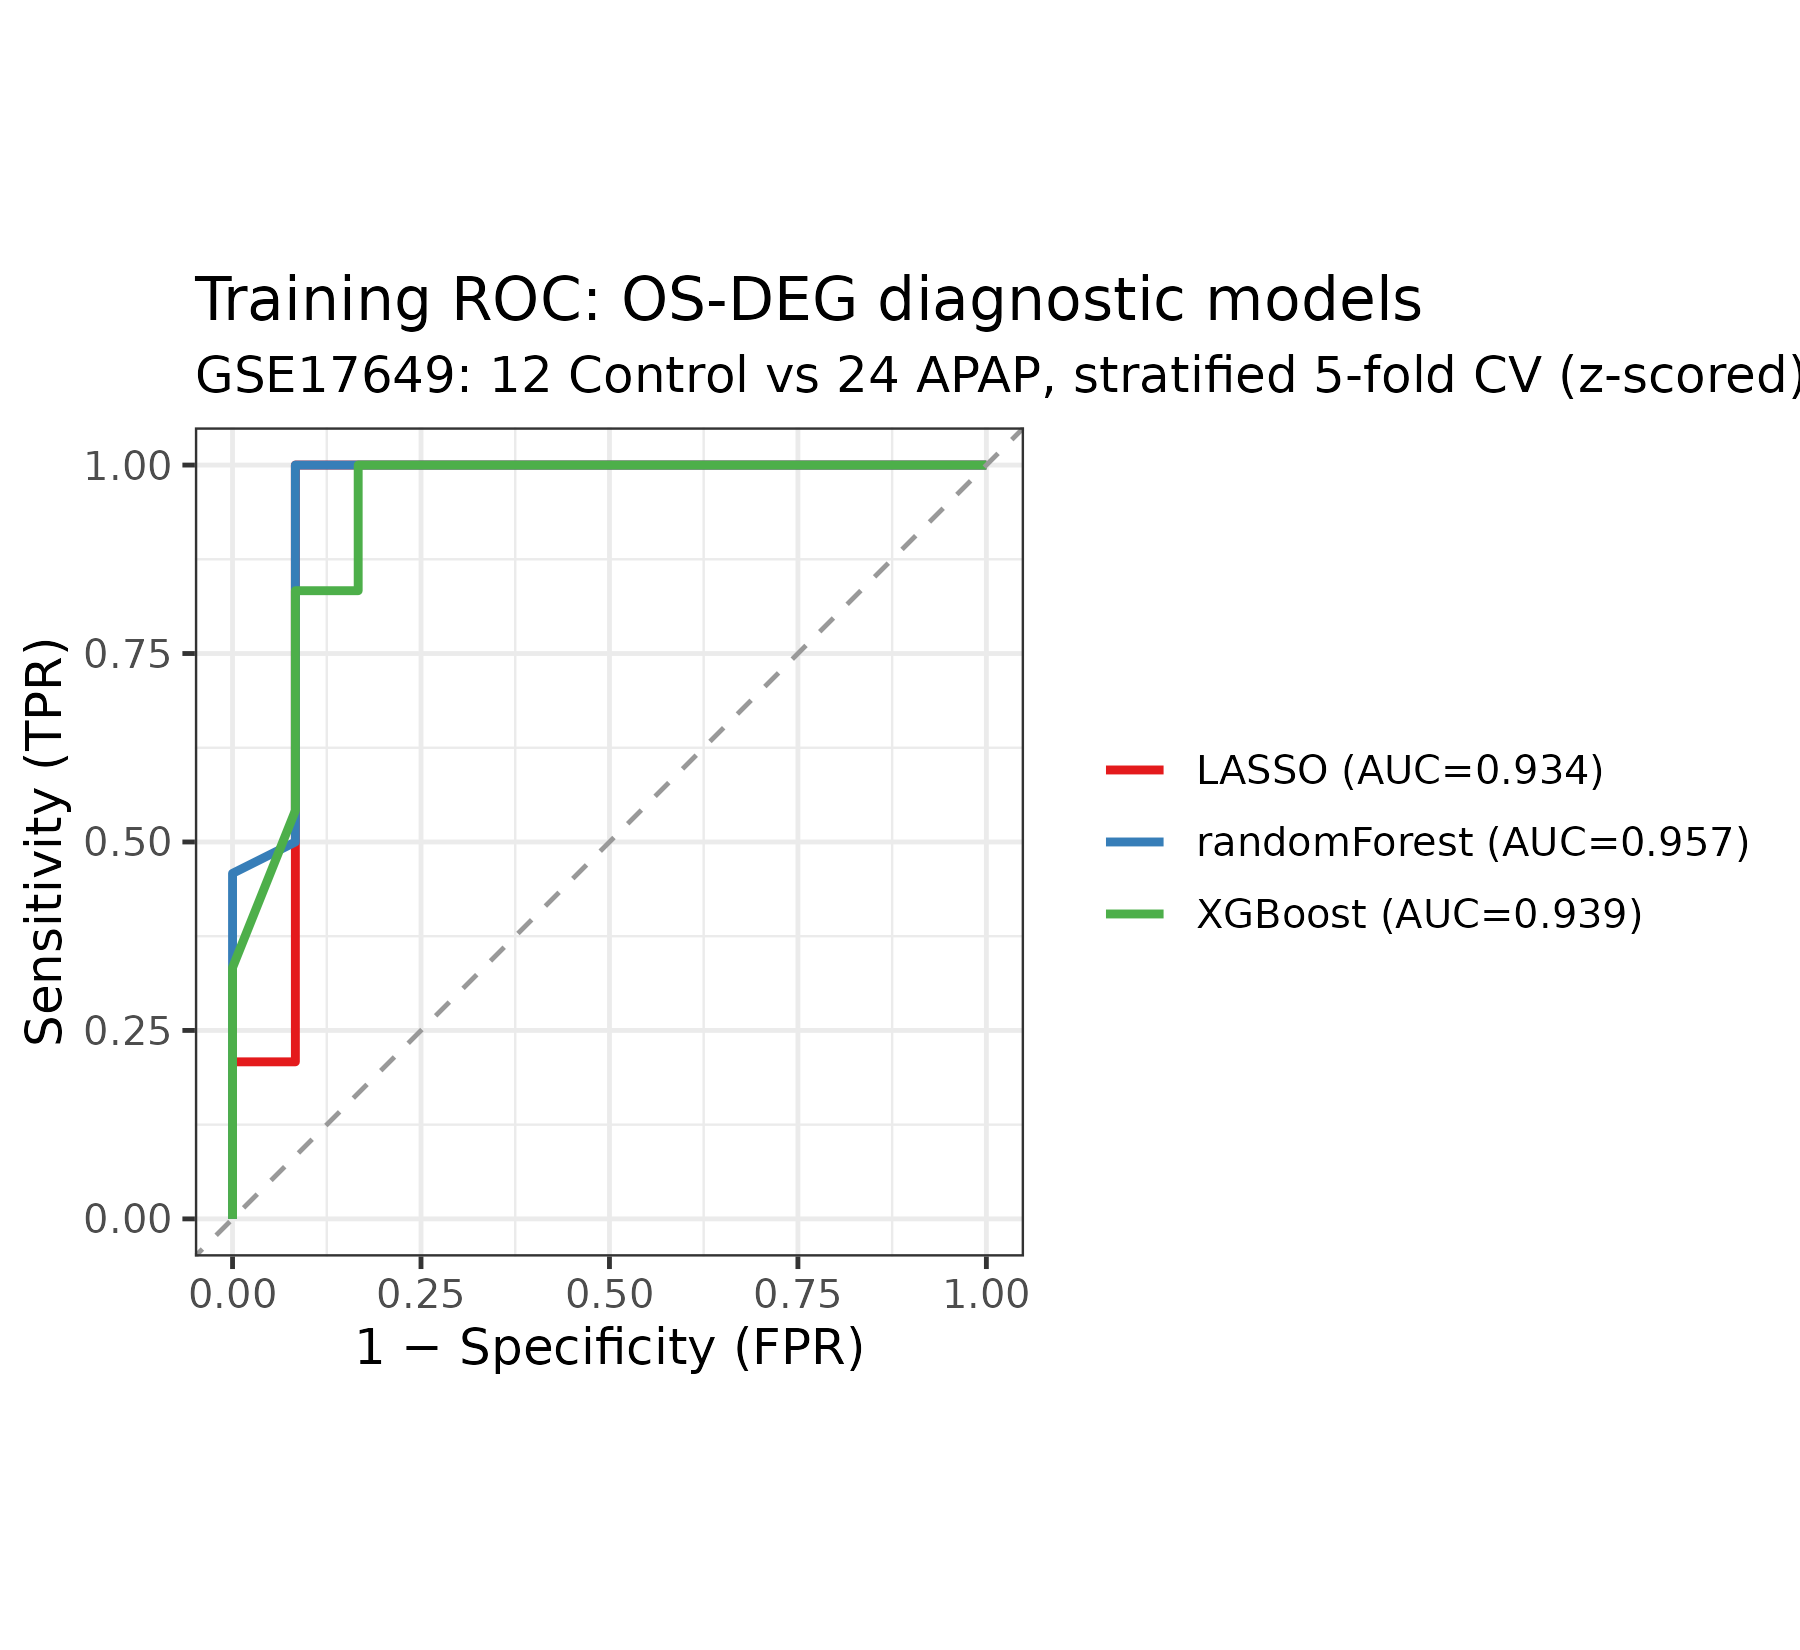

—— results/roc_validation.png


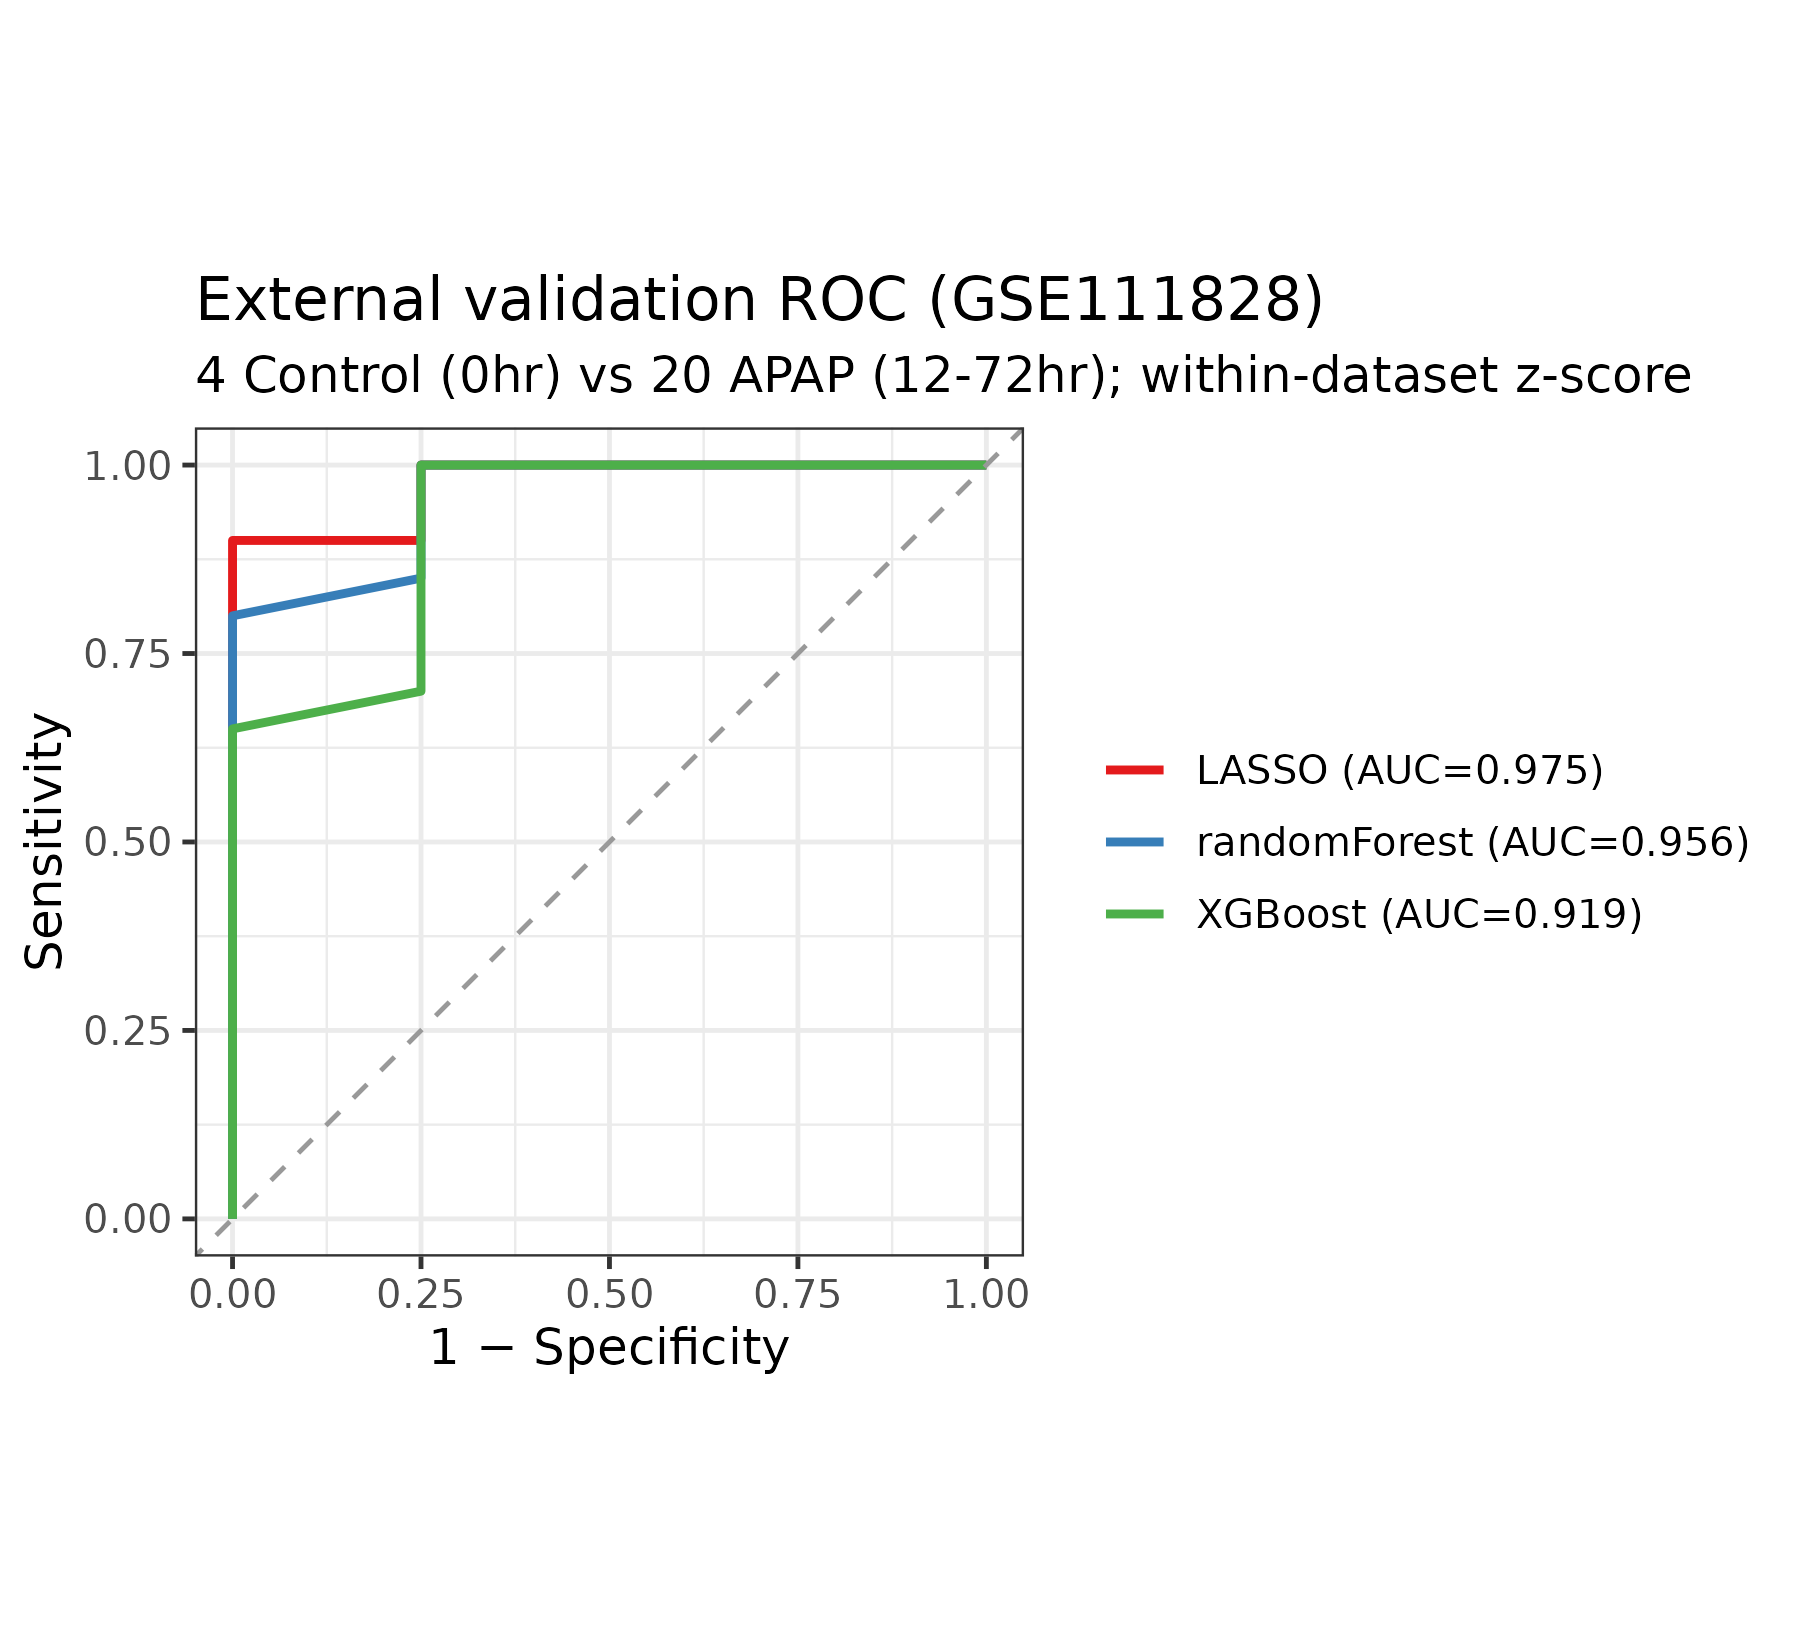

In [10]:
from IPython.display import Image, display
for f in ["roc_training.png", "roc_validation.png"]:
    print(f"—— results/{f}")
    display(Image(filename=str(ROOT / "results" / f), width=420))

## 5. 功能富集(OS-DEGs)

最显著通路为 GO:0006979 "response to oxidative stress"(8/8 基因命中,富集倍数≈39.8),
符合"氧化应激是 APAP 肝损伤核心机制"的生物学先验;KEGG 层面可见 Ferroptosis 等通路。

In [11]:
go = pd.read_csv(ROOT / "results/enrichment_go_BP.csv")
kegg = pd.read_csv(ROOT / "results/enrichment_kegg.csv")
go_top = go.nsmallest(6, "p.adjust")[["ID", "Description", "FoldEnrichment", "p.adjust", "Count"]]
kegg_top = kegg.nsmallest(6, "p.adjust")[["ID", "Description", "FoldEnrichment", "p.adjust", "Count"]]
print("GO Biological Process (top 6 by p.adjust):")
display(go_top)
print("KEGG (top 6 by p.adjust):")
display(kegg_top)

GO Biological Process (top 6 by p.adjust):


,ID,Description,FoldEnrichment,p.adjust,Count
0,GO:0006979,response to oxidative stress,39.841463,6.393083e-11,8
1,GO:0045454,cell redox homeostasis,140.818966,1.503683e-02,2
2,GO:0009636,response to toxic substance,27.717760,1.503683e-02,3
3,GO:0046685,response to arsenic-containing substance,110.371622,1.503683e-02,2
4,GO:0046686,response to cadmium ion,85.078125,2.031937e-02,2
5,GO:0098869,cellular oxidant detoxification,55.941781,3.920881e-02,2


KEGG (top 6 by p.adjust):


,ID,Description,FoldEnrichment,p.adjust,Count
0,mmu04216,Ferroptosis,55.285714,0.012358,2
1,mmu05225,Hepatocellular carcinoma,12.579983,0.114882,2
2,mmu00450,Selenocompound metabolism,65.651786,0.116065,1
3,mmu00860,Porphyrin metabolism,30.012245,0.144856,1
4,mmu04978,Mineral absorption,21.008571,0.144856,1
5,mmu00270,Cysteine and methionine metabolism,20.200549,0.144856,1


—— results/enrichment_dotplot.png (R clusterViewer 输出)


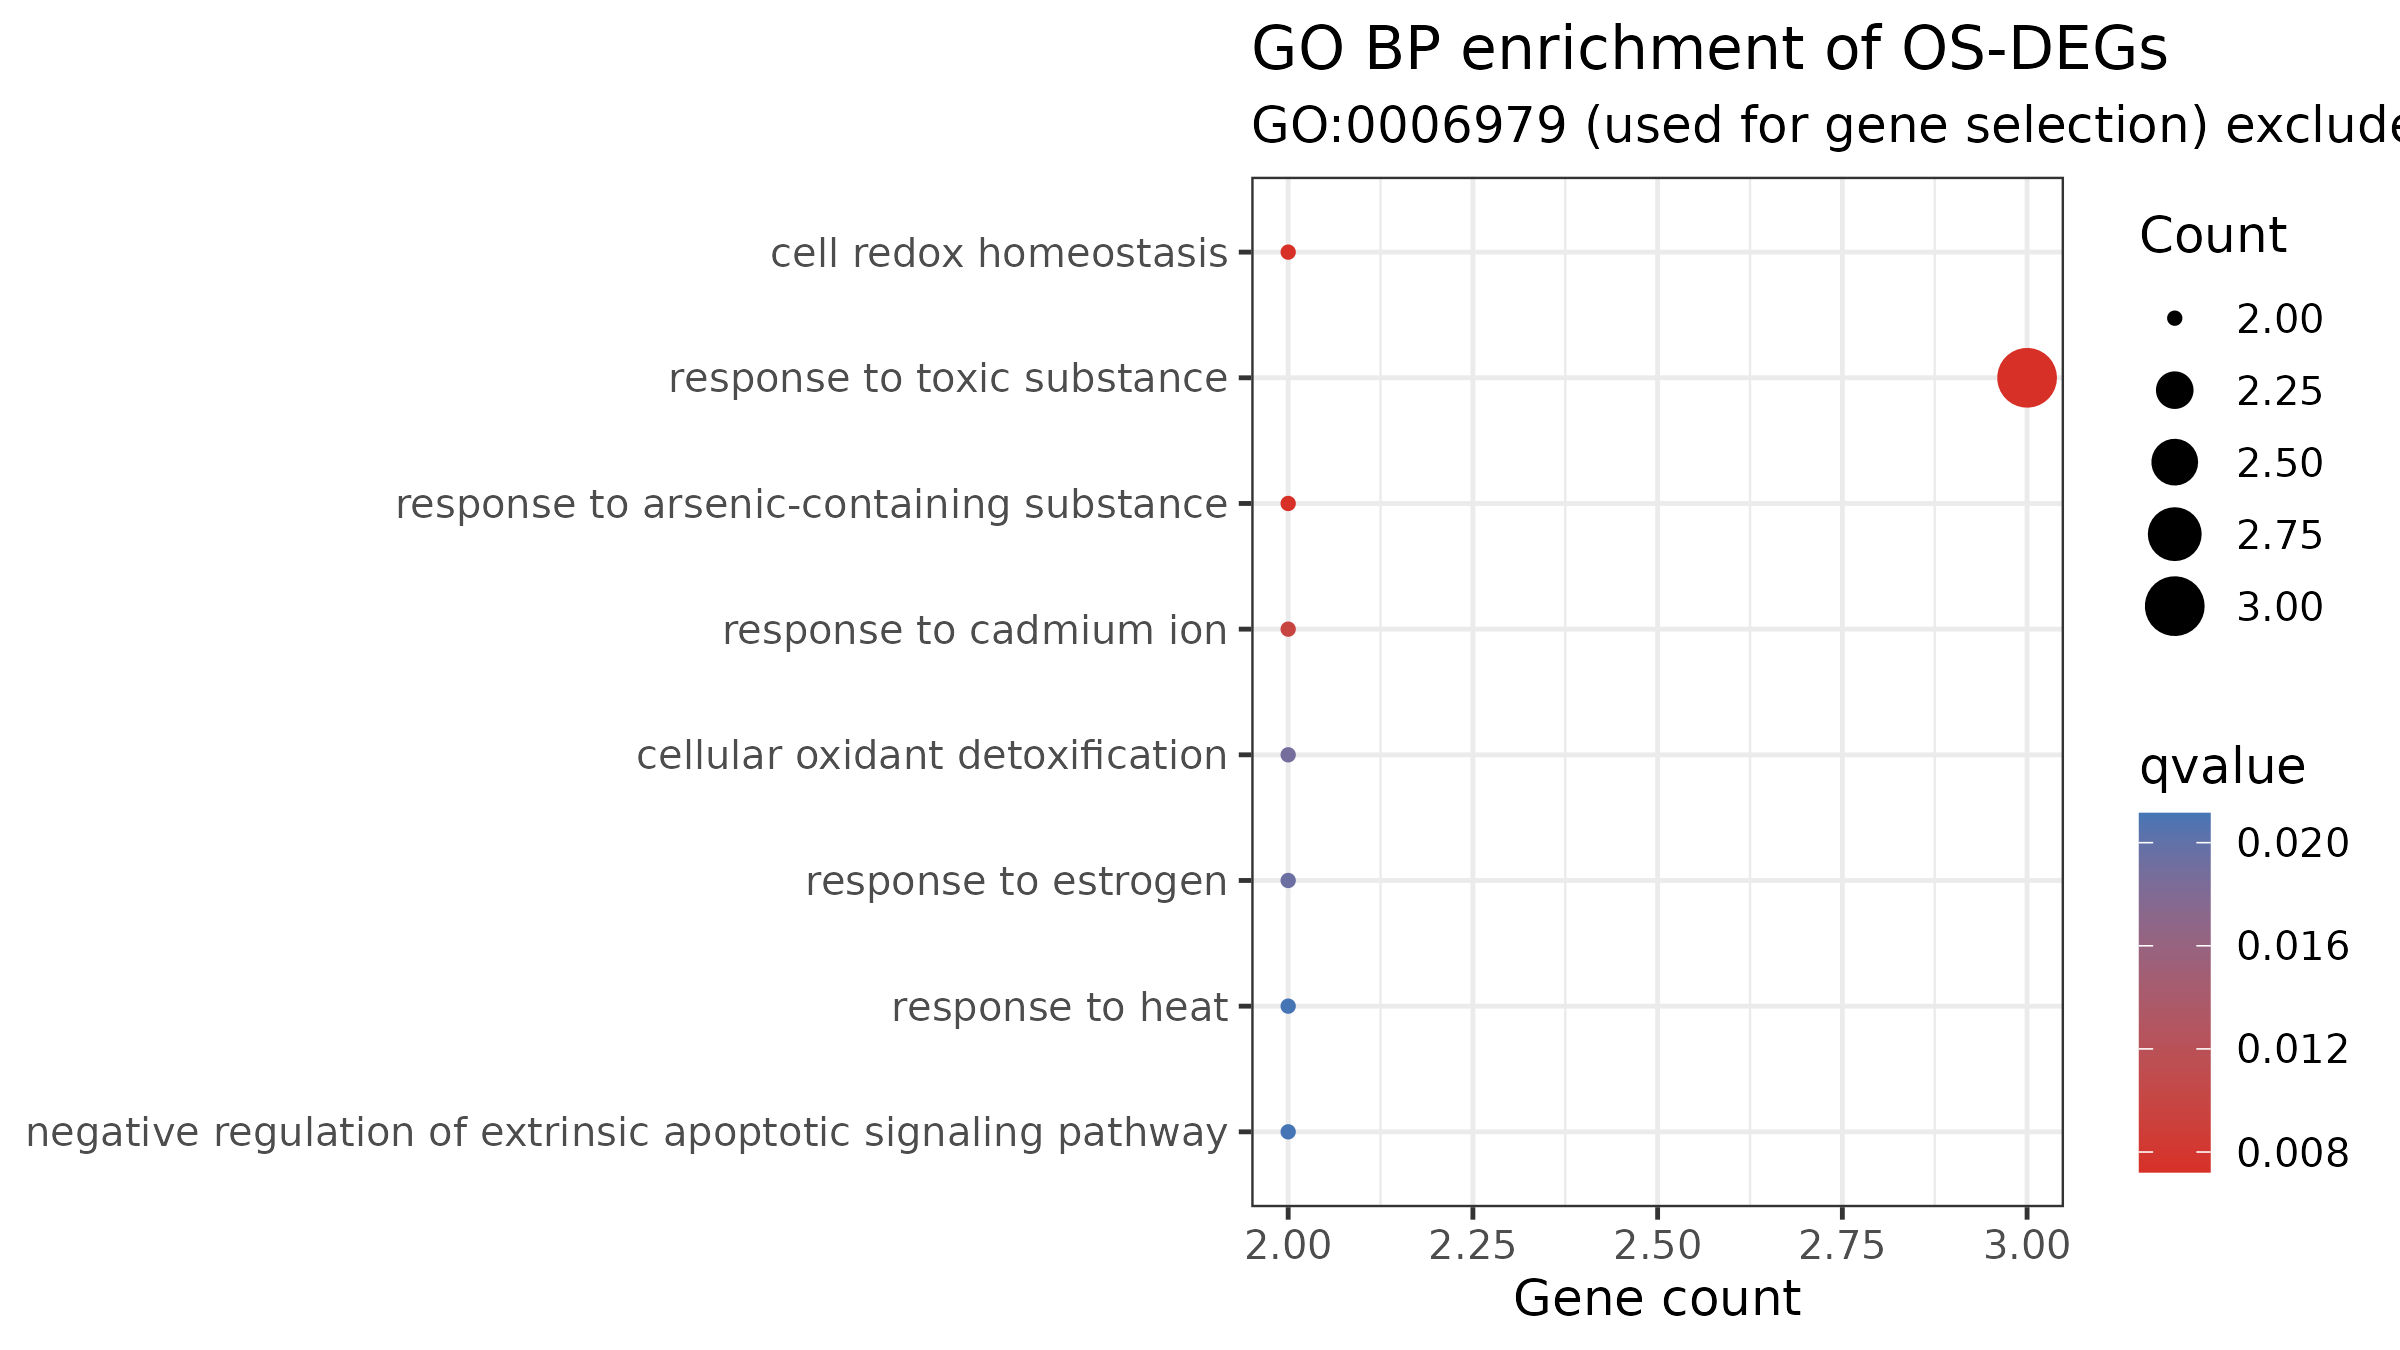

In [12]:
print("—— results/enrichment_dotplot.png (R clusterViewer 输出)")
display(Image(filename=str(ROOT / "results" / "enrichment_dotplot.png"), width=560))

## 6. 跨物种方向一致性(GSE120652, 人 APAP-ALF, n=6)

将 8 个 OS-DEGs 的人同源基因在人类 APAP-ALF 数据中的 logFC 方向与小鼠方向比对(探索性分析):

In [13]:
cs = pd.read_csv(ROOT / "results/crossspecies_GSE120652.csv")
n_conc = int(cs["direction_concordant"].sum())
print(f"方向一致: {n_conc}/{len(cs)}(均未过 FDR,仅作方向性佐证)")
Nrf2_core = ["HMOX1", "SRXN1", "TXNRD1"]
print("Nrf2 核心模块方向一致:",
      all(bool(cs.loc[cs['gene_symbol'] == g, 'direction_concordant'].iloc[0]) for g in Nrf2_core if (cs['gene_symbol'] == g).any()))
cs

方向一致: 5/8(均未过 FDR,仅作方向性佐证)
Nrf2 核心模块方向一致: True


,gene_symbol,logFC,P.Value,adj.P.Val,mouse_logFC,direction_concordant
0,GCLC,-1.041743,0.010928,0.196482,1.416935,False
1,TXNRD1,0.900113,0.077162,0.421469,1.058855,True
2,RCAN1,-0.813290,0.041940,0.328732,1.487573,False
3,ITCH,-0.779480,0.005550,0.151587,-1.184584,True
4,SRXN1,0.707590,0.140713,0.525494,2.613554,True
5,HMOX1,0.466303,0.207130,0.601612,3.833643,True
6,BTG1,-0.305353,0.107322,0.473797,1.885698,False
7,XPA,-0.241733,0.174232,0.565351,-1.444281,True


## 7. 结论

1. GSE17649 中筛选出 **566 个 DEGs**,与氧化应激基因集交集得 **8 个 OS-DEGs**(Hmox1, Srxn1, Gclc, Txnrd1, Rcan1, Btg1, Itch, Xpa);
2. 三种模型的分层 5×5 折交叉验证 AUC 约 **0.93-0.95**;
3. 独立外部集 GSE111828 上 LASSO **AUC=0.975**(灵敏度 0.70 / 特异度 1.00 @0.5),且本笔记本从原始预测概率**重算复核通过**;
4. 富集结果以氧化应激应答为最显著通路;跨物种方向一致性 5/8(Nrf2 核心 HMOX1/SRXN1/TXNRD1 一致),为探索性证据。

**局限**:外部验证概率未校准(区分度≠校准);跨物种样本量极小。方法学细节与已知局限见 README 与 `report/06_report.html`。

**复现路径**

```bash
# A. R 全流程(下载数据→DEG→ML→富集→验证,种子固定)
conda env create -f env/rna.yml && conda activate rna
bash scripts/run_all.sh

# B. 仅复现本笔记本(读取已提交的结果文件)
pip install -r requirements.txt
jupyter lab notebooks/01_results_showcase.ipynb
```

In [14]:
print("会话信息(可复现性存档)")
print(f"  Python     {sys.version.split()[0]} ({platform.system()} {platform.release()})")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  matplotlib {matplotlib.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  SEED       {SEED}")

会话信息(可复现性存档)
  Python     3.12.10 (Windows 11)
  numpy      2.3.5
  pandas     3.0.2
  matplotlib 3.10.9
  scikit-learn 1.9.0
  SEED       42
